### در این مثال، چند مدل یادگیری رگرسیون لجستیک، XGBoost و جنگل تصادفی براساس دیتاست مطالعه الری آموزش داده می شود 
ابتدا دیتاست دانلود و در پوشه کاری قرار داده شود

https://github.com/hojatollahgholami/AI-in-Oil-and-gas-industry/blob/main/ex4-1/predictive_maintenance_data.csv

!pip install xgboost

In [12]:
#!pip install sklearn shap plotly streamlit
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.utils import class_weight

import warnings
warnings.filterwarnings('ignore')

###  فراخوانی داده  و پیش پردازش و تحلیل آماری

In [2]:
file_path = "predictive_maintenance_data.csv"
df = pd.read_csv(file_path)
df.head(20)

,Timestamp,Equipment Type,Temperature,Pressure,Vibration,Humidity,Flow Rate,Failure Mode,Failure Occurred
0,2023-01-01 00:00:00,Pipeline,45.930118,47.477887,1.546891,64.627029,28.936152,Leakage,1
1,2023-01-01 01:00:00,Heat Exchanger,71.251779,42.400536,2.653277,35.176389,80.674306,None,0
2,2023-01-01 02:00:00,Valve,64.614562,54.631287,1.150775,51.528233,19.973044,None,0
3,2023-01-01 03:00:00,Heat Exchanger,58.687242,48.069987,2.392142,54.722954,90.563536,None,0
4,2023-01-01 04:00:00,Heat Exchanger,62.625734,50.910491,1.367394,80.114239,85.637952,None,0
5,2023-01-01 05:00:00,Compressor,76.094085,44.820190,2.942894,60.803544,71.092661,None,0
6,2023-01-01 06:00:00,Valve,88.286408,52.179738,1.227700,73.863982,16.067316,None,0
7,2023-01-01 07:00:00,Valve,78.131845,46.190294,2.576125,31.140444,28.771213,Wear & Tear,1
8,2023-01-01 08:00:00,Valve,68.934966,49.291456,1.959183,57.869560,87.342544,Leakage,1
9,2023-01-01 09:00:00,Heat Exchanger,79.559042,54.389130,1.816699,84.079060,20.977699,None,0


In [3]:
# تخصیص ویژگی ها و هدف
sensor_features = ["Temperature", "Pressure", "Vibration", "Humidity", "Flow Rate"]
target = "Failure Occurred"
# تبدیل مقدار رشته به زمان عددی
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# مدیریت مقادیر گمشده (if any)
#df.fillna(df.median(), inplace=True)

# استانداردسازی داده ها
scaler = StandardScaler()
df[sensor_features] = scaler.fit_transform(df[sensor_features])

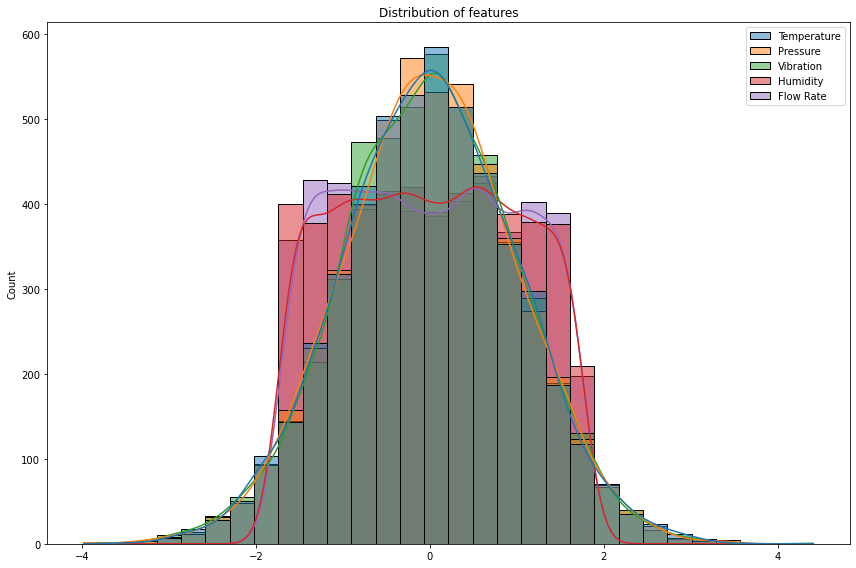

In [4]:
# نمایش توزیع داده ها
plt.figure(figsize=(12, 8))
sns.histplot(df[sensor_features], bins=30, kde=True)
plt.title(f"Distribution of features")
plt.tight_layout()
plt.show()

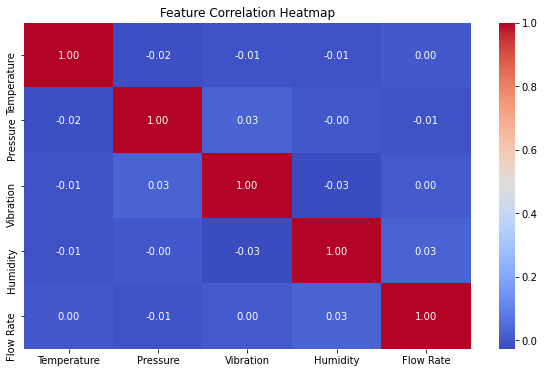

In [5]:
# بررسی همبستگی ویژگی ها
plt.figure(figsize=(10, 6))
sns.heatmap(df[sensor_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

df.to_csv("cleaned_sensor_data.csv", index=False)

### بینش افزایی مجموعه داده

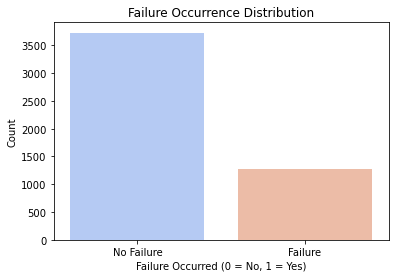

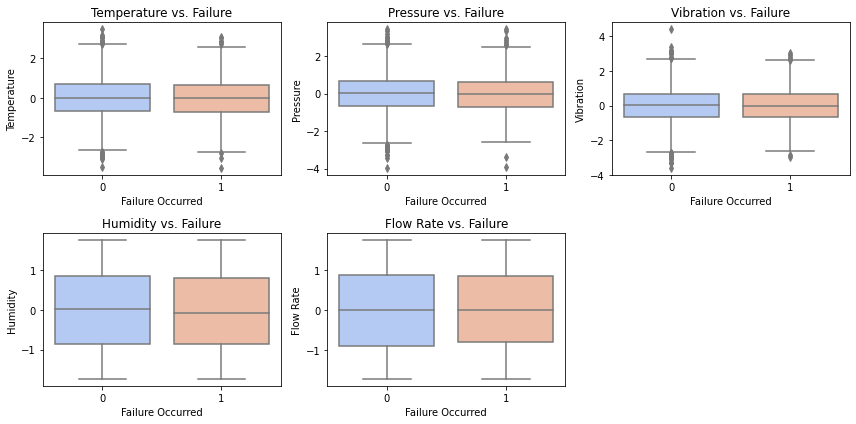

In [6]:
# توزیع خرابی
plt.figure(figsize=(6, 4))
sns.countplot(x="Failure Occurred", data=df, palette="coolwarm")
plt.title("Failure Occurrence Distribution")
plt.xlabel("Failure Occurred (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["No Failure", "Failure"])
plt.show()

# مقادیر سنسورهای مختلف و خرابی
plt.figure(figsize=(12, 6))
for i, feature in enumerate(sensor_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x="Failure Occurred", y=feature, data=df, palette="coolwarm")
    plt.title(f"{feature} vs. Failure")
plt.tight_layout()
plt.show()    

### آموزش مدل ها  

In [7]:
# تعریف ویژگی ها و هدف
X = df[sensor_features]
y = df[target]
#  آماده سازی داده های آموزش و ارزیابی
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Train Logistic Regression Model آموزش مدل رگرسیون لجستیک
log_reg = LogisticRegression(max_iter=500)
#weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
#log_reg = LogisticRegression(max_iter=500, class_weight={0: weights[0], 1: weights[1]})
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [9]:
# Train Random Forest Model use hyperparameters آموزش مدل جنگ تصادفی
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

#param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
#grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
#grid_search.fit(X_train, y_train)
#best_rf = grid_search.best_estimator_

RandomForestClassifier(class_weight='balanced', random_state=42)

In [10]:
# Train XGBoost Model آموزش مدل XGBoost
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

### ارزیابی مدل ها 

=== Logistic Regression Evaluation ===
Accuracy: 0.7500
Classification Report:               precision    recall  f1-score   support

           0       0.75      1.00      0.86       750
           1       0.00      0.00      0.00       250

    accuracy                           0.75      1000
   macro avg       0.38      0.50      0.43      1000
weighted avg       0.56      0.75      0.64      1000



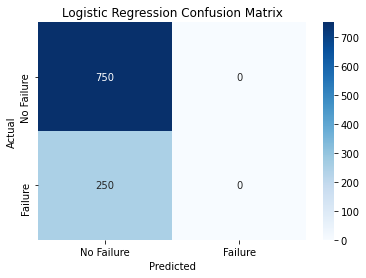

In [13]:
# Evaluate Models
preds = log_reg.predict(X_test)
acc = accuracy_score(y_test, preds)
cm = confusion_matrix(y_test, preds)
    
print(f"=== {'Logistic Regression'} Evaluation ===")
print(f"Accuracy: {acc:.4f}")
print("Classification Report:", classification_report(y_test, preds))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Failure", "Failure"], yticklabels=["No Failure", "Failure"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{'Logistic Regression'} Confusion Matrix")
plt.show()

=== Random Forest Evaluation ===
Accuracy: 0.7430
Classification Report:               precision    recall  f1-score   support

           0       0.75      0.99      0.85       750
           1       0.18      0.01      0.02       250

    accuracy                           0.74      1000
   macro avg       0.47      0.50      0.43      1000
weighted avg       0.61      0.74      0.64      1000



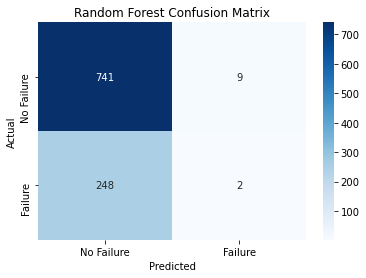

In [14]:
preds = rf_model.predict(X_test)
acc = accuracy_score(y_test, preds)
cm = confusion_matrix(y_test, preds)
    
print(f"=== {'Random Forest'} Evaluation ===")
print(f"Accuracy: {acc:.4f}")
print("Classification Report:", classification_report(y_test, preds))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Failure", "Failure"], yticklabels=["No Failure", "Failure"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{'Random Forest'} Confusion Matrix")
plt.show()

=== XGBoost Evaluation ===
Accuracy: 0.7040
Classification Report:               precision    recall  f1-score   support

           0       0.75      0.91      0.82       750
           1       0.26      0.10      0.14       250

    accuracy                           0.70      1000
   macro avg       0.51      0.50      0.48      1000
weighted avg       0.63      0.70      0.65      1000



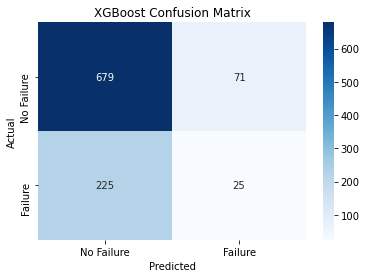

In [15]:
preds = xgb_model.predict(X_test)
acc = accuracy_score(y_test, preds)
cm = confusion_matrix(y_test, preds)
print(f"=== {'XGBoost'} Evaluation ===")
print(f"Accuracy: {acc:.4f}")
print("Classification Report:", classification_report(y_test, preds))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Failure", "Failure"], yticklabels=["No Failure", "Failure"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{'XGBoost'} Confusion Matrix")
plt.show()

# داشبوردسازی با مجموعه داده پردازش شده

In [ ]:
# streamlit run ex41_dashboard.py
import streamlit as st
import plotly.express as px

In [ ]:
# Load data from CSV
@st.cache_data
def load_data():
    return pd.read_csv("cleaned_sensor_data.csv")

df = load_data()
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Dashboard UI
st.title('Predictive Maintenance Dashboard - Oil & Gas Industry')

# Filters
st.sidebar.header('Filters')
equipment_type = st.sidebar.multiselect('Select Equipment Type', df['Equipment Type'].unique(), default=df['Equipment Type'].unique())
failure_occurred = st.sidebar.multiselect('Select Failure Occurred', df['Failure Occurred'].unique(), default=df['Failure Occurred'].unique())

# Apply filters
filtered_df = df[(df['Equipment Type'].isin(equipment_type)) & (df['Failure Occurred'].isin(failure_occurred))]

# Visualizations
st.subheader('Failure Rate Over Time')
failure_trend = filtered_df.groupby('Timestamp')['Failure Occurred'].sum().reset_index()
fig1 = px.line(failure_trend, x='Timestamp', y='Failure Occurred', title='Failures Over Time')
st.plotly_chart(fig1)

st.subheader('Sensor Readings Distribution')
sensor_columns = ["Temperature", "Pressure", "Vibration", "Humidity", "Flow Rate"]
for sensor in sensor_columns:
    fig2 = px.histogram(filtered_df, x=sensor, color='Failure Occurred', marginal='box', title=f'{sensor} Distribution')
    st.plotly_chart(fig2)

st.subheader('Equipment Type vs Failure')
failure_breakdown = filtered_df.groupby('Equipment Type')['Failure Occurred'].sum().reset_index()
fig3 = px.bar(failure_breakdown, x='Equipment Type', y='Failure Occurred', title='Failure Count by Equipment Type')
st.plotly_chart(fig3)


در داشبورد سازی از مجموعه داده پردازش شده استفاده شده است. و از مدل ها بدلیل دقت نامناسب آنها استفاده نشده است. می توان مدل های دیگر را آموزش داد و پس از بهبود دقت آنها، بهره برداری نمود.